# NautiCost — Cost Prediction Modeling

Predict `final_charge` per yacht service transaction.

**Approach:** LightGBM (primary) + Ridge baseline, time-based split, log-transformed target.
See `../../.claude/plans/staged-swimming-treehouse.md` for the full plan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

pd.set_option('display.max_columns', 50)
RNG = 42

## 1. Load data

In [2]:
DATA = Path('../004 data/costs_merged.csv')
df = pd.read_csv(DATA)
print(df.shape)
df.head()

(1654, 26)


,yacht_id,office,arrival_port,arrival_date,departure_date,service_type,invoice_comments,supplier,cost_no_vat,final_charge,year,month,stay_days,margin,service_category,flag,gt,nt,loa_m,reg_length_m,beam_m,draft_m,air_draft_m,fuel_lph,loskrav,size_category
0,yacht_10,Bergen Office,Bergen,2024-09-13 00:00:00,2024-09-21 00:00:00,Repair of,Bike Repair + Bike Pump,Unidentified Supplier,335.68,457.98,2024,9,8.0,122.30,Technical Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
1,yacht_10,Bergen Office,Bergen,2024-09-15 00:00:00,2024-09-25 00:00:00,Transfer Service,Transfer - Embarking + Disembarking Crew,Unidentified Supplier,576.87,917.27,2024,9,10.0,340.40,Hospitality,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
2,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-26 00:00:00,Purchasing Assistance,Purchase Assistance - SD Charts,Unidentified Supplier,201.73,247.15,2024,9,8.0,45.42,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
3,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-26 00:00:00,Custom Formalities,Entry Clearance into Norway,NaN,0.00,251.04,2024,9,8.0,251.04,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
4,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-28 00:00:00,Purchasing Assistance,Purchase Assistance - Beers,Unidentified Supplier,160.86,221.49,2024,9,10.0,60.63,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor


In [3]:
# Drop rows with missing target
df = df.dropna(subset=['final_charge'])
df = df[df['final_charge'] > 0].copy()
print('After filtering:', df.shape)
df['final_charge'].describe()

After filtering: (1633, 26)


count      1633.000000
mean      25044.820269
std       57589.474465
min          15.110000
25%        2039.060000
50%        7512.970000
75%       21950.000000
max      657504.100000
Name: final_charge, dtype: float64

## 2. Features and target

In [4]:
CAT_FEATURES = ['office', 'arrival_port', 'service_type', 'service_category', 'size_category', 'loskrav']
NUM_FEATURES = ['gt', 'loa_m', 'beam_m', 'draft_m', 'stay_days', 'month']
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = 'final_charge'

for c in CAT_FEATURES:
    df[c] = df[c].astype('category')

df[FEATURES].dtypes

office              category
arrival_port        category
service_type        category
service_category    category
size_category       category
loskrav             category
gt                   float64
loa_m                float64
beam_m               float64
draft_m              float64
stay_days            float64
month                  int64
dtype: object

### 2b. Feature engineering
Temporal, interaction, and text-based features derived from existing columns.

In [5]:
def build_features(df, agg_stats=None):
    """Add engineered features.
    agg_stats: tuple of (size_svc_stats, size_stats, port_stats) DataFrames.
    If None, fit on rows where year<=2023.
    """
    df = df.copy()

    # Temporal
    df['quarter'] = ((df['month'] - 1) // 3 + 1).astype('int8')
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype('int8')
    df['is_shoulder'] = df['month'].isin([5, 9]).astype('int8')

    # Time-based features from arrival_date
    if 'arrival_date' in df.columns:
        arr = pd.to_datetime(df['arrival_date'], errors='coerce')
        df['day_of_week'] = arr.dt.dayofweek.fillna(2).astype('int8')   # 0=Mon..6=Sun
        df['week_of_year'] = arr.dt.isocalendar().week.astype('int8')
    else:
        # Synthetic rows (e.g. predict_voyage.py) — default to Wednesday, derive week from month
        df['day_of_week'] = np.int8(2)
        df['week_of_year'] = ((df['month'] - 1) * 4 + 2).clip(1, 52).astype('int8')

    # Numeric interactions
    df['gt_x_stay']   = df['gt'].fillna(0) * df['stay_days'].fillna(0)
    df['loa_x_stay']  = df['loa_m'].fillna(0) * df['stay_days'].fillna(0)
    df['fuel_x_stay'] = df['fuel_lph'].fillna(0) * df['stay_days'].fillna(0)

    # Size-category x service-category aggregates (generalizes to unseen yachts)
    if agg_stats is None:
        hist = df[df['year'] <= 2023]
        size_svc_stats = hist.groupby(['size_category', 'service_category'])['final_charge'].agg(
            size_svc_mean_charge='mean',
            size_svc_median_charge='median',
            size_svc_count='count'
        ).reset_index()
        size_stats = hist.groupby('size_category')['final_charge'].agg(
            size_mean_charge='mean', size_count='count'
        ).reset_index()
        port_stats = hist.groupby('arrival_port')['final_charge'].agg(
            port_mean_charge='mean', port_median_charge='median'
        ).reset_index()
        agg_stats = (size_svc_stats, size_stats, port_stats)

    size_svc_stats, size_stats, port_stats = agg_stats
    df = df.merge(size_svc_stats, on=['size_category', 'service_category'], how='left')
    df = df.merge(size_stats, on='size_category', how='left')
    df = df.merge(port_stats, on='arrival_port', how='left')

    # Fill missing stats with global medians
    for col in ['size_svc_mean_charge', 'size_svc_median_charge', 'size_svc_count',
                'port_mean_charge', 'port_median_charge']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median() if df[col].notna().any() else 0)

    # Text signal from invoice_comments (length only — keyword flags had zero/near-zero importance)
    cmt = df['invoice_comments'].fillna('').astype(str).str.lower()
    df['cmt_len'] = cmt.str.len().astype('int16')

    return df, agg_stats

# Dropped 7 low-importance/redundant features:
#   log_gt (r=0.94 with gt), fuel_lph (r=0.999 with gt), size_mean_charge (gain<1),
#   size_count (gain=0), cmt_has_urgent (0 positives), cmt_has_repair (gain=0), cmt_has_fuel (gain<2)
NEW_NUM = ['quarter','is_summer','is_shoulder','day_of_week','week_of_year',
           'gt_x_stay','loa_x_stay','fuel_x_stay',
           'size_svc_mean_charge','size_svc_median_charge','size_svc_count',
           'port_mean_charge','port_median_charge',
           'cmt_len']
NUM_FEATURES = NUM_FEATURES + NEW_NUM
FEATURES = CAT_FEATURES + NUM_FEATURES

df, agg_stats = build_features(df)
print(f'Total features: {len(FEATURES)} ({len(CAT_FEATURES)} cat + {len(NUM_FEATURES)} num)')
print('Engineered features:', NEW_NUM)

Total features: 26 (6 cat + 20 num)
Engineered features: ['quarter', 'is_summer', 'is_shoulder', 'day_of_week', 'week_of_year', 'gt_x_stay', 'loa_x_stay', 'fuel_x_stay', 'size_svc_mean_charge', 'size_svc_median_charge', 'size_svc_count', 'port_mean_charge', 'port_median_charge', 'cmt_len']


## 3. Time-based split
train ≤ 2023, val = 2024, test = 2025

In [6]:
train = df[df['year'] <= 2023]
val   = df[df['year'] == 2024]
test  = df[df['year'] == 2025]
print('train', train.shape, 'val', val.shape, 'test', test.shape)

# Winsorize extreme targets at P99 during training to limit outlier influence
# (evaluation always uses original values)
P99 = train[TARGET].quantile(0.99)
print(f'Training target P99 cap: {P99:,.0f} NOK  (affects {(train[TARGET] > P99).sum()} rows)')

def xy(sub, cap=None):
    X = sub[FEATURES].copy()
    y_raw = sub[TARGET].values.copy()
    if cap is not None:
        y_raw = np.minimum(y_raw, cap)
    y = np.log1p(y_raw)
    return X, y

X_tr, y_tr = xy(train, cap=P99)
X_va, y_va = xy(val)        # no cap on validation — evaluate on true values
X_te, y_te = xy(test)

train (487, 42) val (490, 42) test (649, 42)
Training target P99 cap: 262,451 NOK  (affects 5 rows)


## 4. Baseline: median predictor & Ridge

In [7]:
def eval_pred(y_true_log, y_pred_log, label):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE with floor of 500 NOK to avoid tiny charges inflating the metric
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 500))) * 100
    print(f'{label:20s} MAE={mae:10.0f}  RMSE={rmse:10.0f}  MAPE={mape:6.1f}%')
    return mae, rmse, mape

med = np.median(y_tr)
eval_pred(y_va, np.full_like(y_va, med), 'Median baseline')

Median baseline      MAE=     21800  RMSE=     60128  MAPE= 300.8%


(21800.0818367347,
 np.float64(60128.467151198594),
 np.float64(300.79777684752383))

In [8]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
])
ridge = Pipeline([('pre', pre), ('reg', Ridge(alpha=1.0, random_state=RNG))])
ridge.fit(X_tr.fillna(-1), y_tr)
eval_pred(y_va, ridge.predict(X_va.fillna(-1)), 'Ridge (val)')

Ridge (val)          MAE=     18251  RMSE=     55842  MAPE= 152.7%


(18250.511479273886,
 np.float64(55842.225574298136),
 np.float64(152.7425102989043))

## 5. LightGBM

In [9]:
lgb_params = dict(
    objective='huber',
    alpha=1.0,           # Huber delta — robust to outlier transactions
    metric='mae',
    learning_rate=0.05,
    num_leaves=40,
    min_data_in_leaf=30,
    max_depth=6,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    random_state=RNG,
    verbose=-1,
)

dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
dval   = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtrain)

model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.637482	val's l1: 0.879084


[200]	train's l1: 0.532912	val's l1: 0.848554


[300]	train's l1: 0.475696	val's l1: 0.836319


[400]	train's l1: 0.430768	val's l1: 0.83495
Early stopping, best iteration is:
[374]	train's l1: 0.442005	val's l1: 0.832506


In [10]:
pred_va = model.predict(X_va, num_iteration=model.best_iteration)
eval_pred(y_va, pred_va, 'LightGBM (val)')

if len(X_te):
    pred_te = model.predict(X_te, num_iteration=model.best_iteration)
    eval_pred(y_te, pred_te, 'LightGBM (test)')

LightGBM (val)       MAE=     17317  RMSE=     54476  MAPE= 180.2%
LightGBM (test)      MAE=     18765  RMSE=     60382  MAPE= 200.2%


## 6. Feature importance

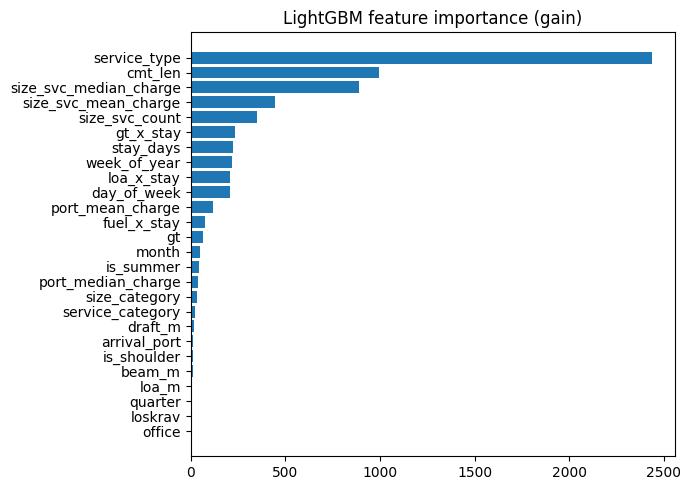

In [11]:
imp = pd.DataFrame({
    'feature': model.feature_name(),
    'gain': model.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'], imp['gain'])
ax.set_title('LightGBM feature importance (gain)')
plt.tight_layout()
plt.show()

## 7. Quantile predictions (P10 / P50 / P90)

In [12]:
# Quantile models are trained after Optuna tuning (see section 9b below)
# to use the tuned hyperparameters for better calibration.
print('Quantile models will be trained after hyperparameter tuning (section 9b).')

Quantile models will be trained after hyperparameter tuning (section 9b).


## 8. CatBoost (native categorical handling)

In [13]:
from catboost import CatBoostRegressor

X_tr_cb = X_tr.copy()
X_va_cb = X_va.copy()
for c in CAT_FEATURES:
    X_tr_cb[c] = X_tr_cb[c].astype(str).fillna('NA')
    X_va_cb[c] = X_va_cb[c].astype(str).fillna('NA')

cb = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=6,
    loss_function='MAE', cat_features=CAT_FEATURES,
    early_stopping_rounds=50, random_seed=RNG, verbose=0,
)
cb.fit(X_tr_cb, y_tr, eval_set=(X_va_cb, y_va))
eval_pred(y_va, cb.predict(X_va_cb), 'CatBoost (val)')

CatBoost (val)       MAE=     17404  RMSE=     55672  MAPE= 174.1%


(17404.028319547728,
 np.float64(55672.15417456657),
 np.float64(174.07255986148772))

## 9. Hyperparameter tuning with Optuna (LightGBM)

In [14]:
import optuna
from sklearn.model_selection import KFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Combine train + val for CV (test=2025 stays fully held out)
X_cv = pd.concat([X_tr, X_va], ignore_index=True)
y_cv = np.concatenate([y_tr, y_va])

def objective(trial):
    p = dict(
        objective='huber', metric='mae', verbose=-1, random_state=RNG,
        alpha=trial.suggest_float('alpha', 0.5, 5.0),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 50),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 25, 80),
        max_depth=trial.suggest_int('max_depth', 3, 6),
        feature_fraction=trial.suggest_float('feature_fraction', 0.5, 0.85),
        bagging_fraction=trial.suggest_float('bagging_fraction', 0.5, 0.85),
        bagging_freq=5,
        lambda_l1=trial.suggest_float('lambda_l1', 0.1, 10, log=True),
        lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10, log=True),
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=RNG)
    fold_maes = []
    for train_idx, val_idx in kf.split(X_cv):
        Xf_tr, yf_tr = X_cv.iloc[train_idx], y_cv[train_idx]
        Xf_va, yf_va = X_cv.iloc[val_idx], y_cv[val_idx]
        dtr = lgb.Dataset(Xf_tr, yf_tr, categorical_feature=CAT_FEATURES)
        dva = lgb.Dataset(Xf_va, yf_va, categorical_feature=CAT_FEATURES, reference=dtr)
        m = lgb.train(p, dtr, num_boost_round=1500, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        pred = m.predict(Xf_va, num_iteration=m.best_iteration)
        fold_maes.append(mean_absolute_error(np.expm1(yf_va), np.expm1(pred)))
    return np.mean(fold_maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=80, show_progress_bar=False)
print('Best CV MAE:', study.best_value)
print('Best params:', study.best_params)

Best CV MAE: 15785.527282552735
Best params: {'alpha': 3.3476882604290616, 'learning_rate': 0.03226541384558654, 'num_leaves': 32, 'min_data_in_leaf': 47, 'max_depth': 6, 'feature_fraction': 0.8492401252496345, 'bagging_fraction': 0.8336695854523456, 'lambda_l1': 0.3440656163120011, 'lambda_l2': 0.0033834895213130656}


In [15]:
# Train tuned model on original train split, validate on val split (for comparison with base models)
tuned_params = dict(objective='huber', metric='mae', verbose=-1,
                    random_state=RNG, bagging_freq=5, **study.best_params)
dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtr)
best_model = lgb.train(
    tuned_params, dtr, num_boost_round=2000, valid_sets=[dtr, dva],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
pred_tr = best_model.predict(X_tr, num_iteration=best_model.best_iteration)
pred_va = best_model.predict(X_va, num_iteration=best_model.best_iteration)
eval_pred(y_tr, pred_tr, 'Tuned LGB (train)')
eval_pred(y_va, pred_va, 'Tuned LGB (val)')

# Report train/val gap
tr_l1 = mean_absolute_error(y_tr, pred_tr)
va_l1 = mean_absolute_error(y_va, pred_va)
print(f'\nTrain/val log-L1 gap: {tr_l1:.4f} / {va_l1:.4f} = {va_l1/tr_l1:.1f}x')

Tuned LGB (train)    MAE=     12435  RMSE=     31838  MAPE=  77.6%
Tuned LGB (val)      MAE=     17837  RMSE=     55141  MAPE= 168.9%

Train/val log-L1 gap: 0.5905 / 0.8699 = 1.5x


### 9a. LightGBM + CatBoost ensemble
Blend log-space predictions from LightGBM (tuned) and CatBoost. Grid-search the optimal weight on the validation set.

In [16]:
# Ensemble: blend LightGBM (tuned) + CatBoost predictions in log-space
lgb_pred_va = best_model.predict(X_va, num_iteration=best_model.best_iteration)
cb_pred_va  = cb.predict(X_va_cb)

# Grid search for optimal blending weight
best_w, best_ens_mae = None, float('inf')
for w_lgb in np.arange(0.3, 0.75, 0.05):
    ens = w_lgb * lgb_pred_va + (1 - w_lgb) * cb_pred_va
    mae = mean_absolute_error(np.expm1(y_va), np.expm1(ens))
    if mae < best_ens_mae:
        best_w, best_ens_mae = w_lgb, mae

ens_pred = best_w * lgb_pred_va + (1 - best_w) * cb_pred_va
ens_mae = mean_absolute_error(np.expm1(y_va), np.expm1(ens_pred))
ens_rmse = np.sqrt(mean_squared_error(np.expm1(y_va), np.expm1(ens_pred)))
ens_mape = np.mean(np.abs((np.expm1(y_va) - np.expm1(ens_pred)) / np.maximum(np.expm1(y_va), 500))) * 100

# Individual model metrics for comparison
lgb_mae = mean_absolute_error(np.expm1(y_va), np.expm1(lgb_pred_va))
cb_mae  = mean_absolute_error(np.expm1(y_va), np.expm1(cb_pred_va))

print(f'Ensemble weight: {best_w:.2f} LightGBM + {1-best_w:.2f} CatBoost')
print(f'Ensemble (val)       MAE={ens_mae:10.0f}  RMSE={ens_rmse:10.0f}  MAPE={ens_mape:6.1f}%')
print()
print('Comparison:')
print(f'  LightGBM (tuned):  MAE={lgb_mae:10.0f}')
print(f'  CatBoost:          MAE={cb_mae:10.0f}')
print(f'  Ensemble:          MAE={ens_mae:10.0f}  {"<-- BEST" if ens_mae < min(lgb_mae, cb_mae) else ""}')

Ensemble weight: 0.30 LightGBM + 0.70 CatBoost
Ensemble (val)       MAE=     17350  RMSE=     55490  MAPE= 168.3%

Comparison:
  LightGBM (tuned):  MAE=     17837
  CatBoost:          MAE=     17404
  Ensemble:          MAE=     17350  <-- BEST


### 9b. Quantile predictions with tuned params + CQR calibration

In [17]:
# Quantile models need UNCAPPED targets to learn the true distribution
# (the main model uses Winsorized targets, but quantiles must reflect real extremes)
y_tr_uncapped = np.log1p(train[TARGET].values)

# Train wider quantiles (0.05/0.95) so raw intervals cover ~80%,
# then fine-tune with CQR for exact calibration
quantile_models = {}
for q in [0.05, 0.5, 0.95]:
    p = {**tuned_params, 'objective': 'quantile', 'alpha': q, 'metric': 'quantile',
         'feature_pre_filter': False}
    # Lighter regularisation for extreme quantiles — let the tails spread
    p['min_data_in_leaf'] = 15
    p['num_leaves'] = 40
    p['lambda_l1'] = 0.1
    p['lambda_l2'] = 0.1
    p['learning_rate'] = 0.05
    dtr_q = lgb.Dataset(X_tr, y_tr_uncapped, categorical_feature=CAT_FEATURES)
    dva_q = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtr_q)
    m = lgb.train(p, dtr_q, num_boost_round=3000, valid_sets=[dva_q],
                  callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
    quantile_models[q] = m
    print(f'  Q{q:.2f}: best_iteration={m.best_iteration}')

# Raw quantile predictions
p10_raw = np.expm1(quantile_models[0.05].predict(X_va))
p50_raw = np.expm1(quantile_models[0.5].predict(X_va))
p90_raw = np.expm1(quantile_models[0.95].predict(X_va))
actual = np.expm1(y_va)

# Fix quantile crossing: sort per-row so P10 <= P50 <= P90
stacked = np.column_stack([p10_raw, p50_raw, p90_raw])
stacked_sorted = np.sort(stacked, axis=1)
p10, p50, p90 = stacked_sorted[:, 0], stacked_sorted[:, 1], stacked_sorted[:, 2]

# Conformal Quantile Regression (CQR) correction for guaranteed coverage
scores = np.maximum(p10 - actual, actual - p90)
cqr_alpha = 0.2  # Target 80% coverage
q_correction = np.quantile(scores, 1 - cqr_alpha)
p10_adj = p10 - q_correction
p90_adj = p90 + q_correction

print(f'\nCQR correction: {q_correction:,.0f} NOK')
print()

# Coverage check
cov_raw = np.mean((actual >= p10) & (actual <= p90)) * 100
cov_adj = np.mean((actual >= p10_adj) & (actual <= p90_adj)) * 100
print(f'[P5, P95] raw coverage:       {cov_raw:5.1f}%  (nominal 80%)')
print(f'[P5, P95] CQR-adj coverage:   {cov_adj:5.1f}%  (nominal 80%)')
print()

out = pd.DataFrame({
    'actual': actual,
    'p10': p10_adj, 'p50': p50, 'p90': p90_adj,
}).head(15)
out

  Q0.05: best_iteration=22


  Q0.50: best_iteration=205


  Q0.95: best_iteration=321



CQR correction: 3 NOK

[P5, P95] raw coverage:        79.8%  (nominal 80%)
[P5, P95] CQR-adj coverage:    80.0%  (nominal 80%)



,actual,p10,p50,p90
0,457.98,1218.414776,9085.257620,19928.404443
1,917.27,421.861846,4558.726119,17661.670922
2,247.15,711.723395,1714.950881,10556.083057
3,251.04,878.705547,2108.657152,22694.389476
4,221.49,674.076306,1633.452440,10279.175970
5,466.12,1251.279100,8944.950646,28404.927270
6,4197.39,1266.640451,6675.869584,26596.513941
7,140.80,1254.718277,2558.730890,17355.814060
8,186.45,949.358968,5783.038049,39645.614470
9,159.41,967.541880,5080.437974,41511.621105


## 10. SHAP explainability

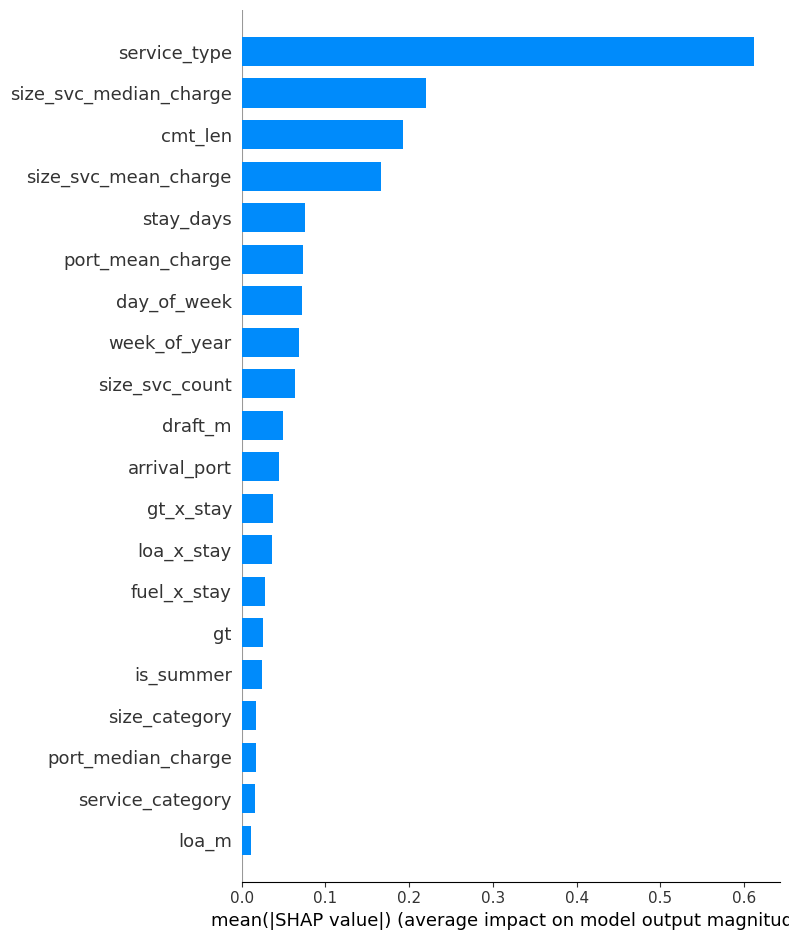

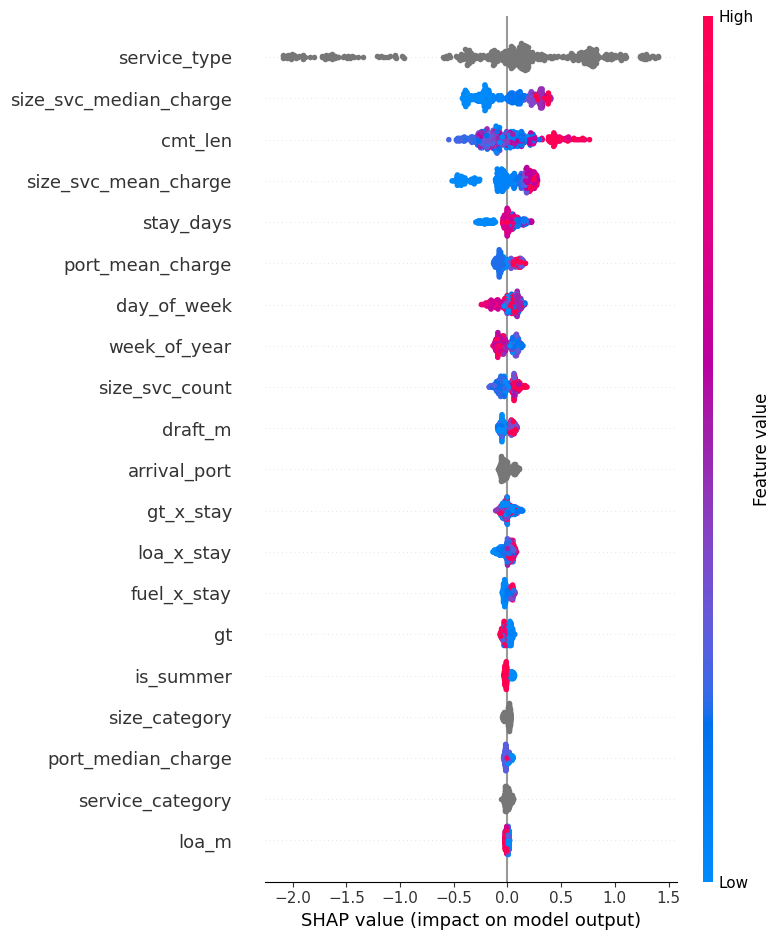

In [18]:
try:
    import shap
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_va)
    shap.summary_plot(shap_values, X_va, plot_type='bar', show=False)
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_values, X_va, show=False)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'SHAP unavailable ({e}), skipping explainability plots.')

In [19]:
try:
    # Per-row explanation: top 5 rows with largest prediction
    pred_va = best_model.predict(X_va, num_iteration=best_model.best_iteration)
    top_idx = np.argsort(-pred_va)[:5]
    for i in top_idx:
        print(f"row={i}  actual={np.expm1(y_va[i]):,.0f}  predicted={np.expm1(pred_va[i]):,.0f}")
        contribs = pd.Series(shap_values[i], index=FEATURES).sort_values(key=np.abs, ascending=False)
        print(contribs.head(5).to_string(), '\n')
except NameError:
    print('SHAP values not available, skipping per-row explanations.')

row=96  actual=76,754  predicted=73,046
service_type              1.094823
size_svc_median_charge    0.376107
size_svc_mean_charge      0.251545
cmt_len                   0.224595
week_of_year              0.092969 

row=78  actual=65,410  predicted=70,484
service_type              1.106560
size_svc_median_charge    0.384743
size_svc_mean_charge      0.252008
cmt_len                   0.235399
week_of_year              0.089119 

row=217  actual=178,252  predicted=70,399
service_type              1.051035
size_svc_median_charge    0.349377
size_svc_mean_charge      0.237266
gt_x_stay                 0.139680
week_of_year              0.095030 

row=275  actual=82,254  predicted=68,622
service_type              0.794755
cmt_len                   0.588299
size_svc_median_charge    0.300312
size_svc_mean_charge      0.185281
stay_days                 0.160834 

row=55  actual=70,248  predicted=62,427
service_type              1.060717
size_svc_median_charge    0.378348
size_svc_mean_charg

## 11. Residual diagnostics
Where does the tuned model err? Look at residuals vs predicted, by segment, and inspect the worst misses.

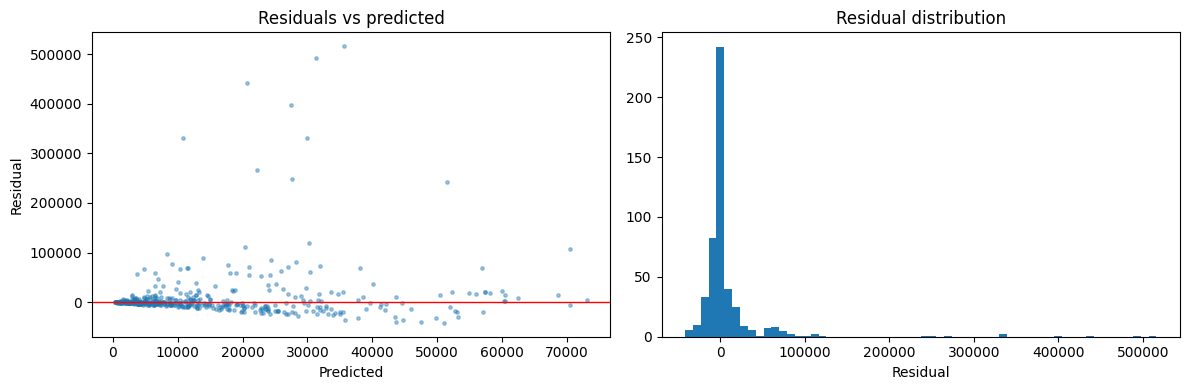

Mean residual:   9,646
Median residual: -421
Std residual:    54,290


In [20]:
pred_va_lin = np.expm1(best_model.predict(X_va, num_iteration=best_model.best_iteration))
actual_va = np.expm1(y_va)
resid = actual_va - pred_va_lin

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_va_lin, resid, s=6, alpha=0.4)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual'); axes[0].set_title('Residuals vs predicted')
axes[1].hist(resid, bins=60)
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()

print(f'Mean residual:   {resid.mean():,.0f}')
print(f'Median residual: {np.median(resid):,.0f}')
print(f'Std residual:    {resid.std():,.0f}')

In [21]:
diag = val[FEATURES + [TARGET]].copy()
diag['pred'] = pred_va_lin
diag['abs_err'] = np.abs(resid)
diag['ape'] = diag['abs_err'] / np.maximum(diag[TARGET], 1)

by_service = diag.groupby('service_category', observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By service_category:'); print(by_service, '\n')

by_size = diag.groupby('size_category', observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By size_category:'); print(by_size)

By service_category:
                      n           mae      mape
service_category                               
Provisioning         49  53255.859438  4.589082
Bunkering            10  29656.796839  0.840563
Port Marina         113  22534.082208  1.361768
Technical Services   40  15876.399226  1.364222
Hospitality          73  14568.650207  1.627042
Agency Fee           16  11619.411384  3.655679
Agency Services     189   7425.010680  3.441758 

By size_category:
                 n           mae      mape
size_category                             
Stor           218  28562.335018  4.073698
Liten          159   9276.623179  0.887827
Mellomstor     113   9191.940582  2.126071


In [22]:
worst = diag.nlargest(10, 'abs_err')[['service_category','size_category','gt','stay_days', TARGET,'pred','abs_err']]
worst

,service_category,size_category,gt,stay_days,final_charge,pred,abs_err
756,Provisioning,Stor,2407.0,11.0,551743.25,35626.537404,516116.712596
842,Port Marina,Stor,2149.0,26.0,522997.98,31328.656370,491669.323630
702,Hospitality,Stor,2407.0,6.0,461675.52,20661.392811,441014.127189
718,Provisioning,Stor,2407.0,4.0,425818.86,27512.605968,398306.254032
874,Port Marina,Stor,2149.0,28.0,342609.85,10783.138982,331826.711018
668,Provisioning,Stor,2407.0,4.0,360872.43,29983.122447,330889.307553
696,Provisioning,Stor,2407.0,6.0,289184.82,22234.425853,266950.394147
835,Provisioning,Stor,2149.0,28.0,276108.37,27676.956548,248431.413452
690,Port Marina,Stor,2407.0,9.0,292987.59,51455.732948,241531.857052
515,Bunkering,Mellomstor,206.0,3.0,149118.15,30225.712278,118892.437722


In [23]:
# Per (service_category x size_category) breakdown — shows where outlier errors concentrate
cross = diag.groupby(['service_category', 'size_category'], observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By service_category x size_category (top 10 by MAE):')
print(cross.head(10).to_string())
print()
print(f'Note: Provisioning/Stor and Port Marina/Stor dominate errors.')
print(f'These are bulk orders (crew provisions, port fees for large vessels)')
print(f'where cost depends on what was ordered, not yacht specs.')

By service_category x size_category (top 10 by MAE):
                                   n           mae      mape
service_category   size_category                            
Bunkering          Mellomstor      3  76314.742116  0.494407
Provisioning       Stor           40  62999.505804  5.262231
Port Marina        Stor           67  32481.495077  1.392946
Technical Services Stor           10  23471.434586  0.905053
Hospitality        Stor           34  22840.047897  1.631771
Technical Services Liten          22  13799.596297  0.522832
Provisioning       Mellomstor      6  13384.067316  2.355276
Agency Fee         Stor            9  12448.155759  6.097320
Technical Services Mellomstor      8  12093.813078  4.252007
Agency Fee         Mellomstor      7  10553.882903  0.516426

Note: Provisioning/Stor and Port Marina/Stor dominate errors.
These are bulk orders (crew provisions, port fees for large vessels)
where cost depends on what was ordered, not yacht specs.


## 12. Final test-set evaluation & model artifact

In [24]:
if len(X_te):
    pred_te = best_model.predict(X_te, num_iteration=best_model.best_iteration)
    eval_pred(y_te, pred_te, 'Tuned LightGBM (test)')
else:
    print('No 2025 test rows available.')

Tuned LightGBM (test) MAE=     19331  RMSE=     61324  MAPE= 200.0%


In [25]:
import joblib
ART = Path('artifacts'); ART.mkdir(exist_ok=True)
best_model.save_model(str(ART / 'lgbm_tuned.txt'))
joblib.dump({'features': FEATURES, 'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
             'best_params': study.best_params, 'best_iteration': best_model.best_iteration},
            ART / 'model_meta.joblib')
print('Saved to', ART.resolve())

Saved to C:\Users\jorge\OneDrive - Høgskolen i Molde\LOG650 - Forskningsprosjekt\LOG650_NautiCost\G11-jorgen-individuell\013 fase 3 - review\artifacts


## 13. Final production model — refit on ALL data
Retrain LightGBM with the tuned hyperparameters on train + val + test combined, using `best_iteration` from the validation-tuned model (no early stopping possible without a holdout).

In [26]:
df_final = df[df['year'].between(2020, 2025)].copy()
X_all = df_final[FEATURES].copy()
y_all = np.log1p(df_final[TARGET].values)
print('Full dataset:', X_all.shape, '| years:', sorted(df_final['year'].unique()))

dall = lgb.Dataset(X_all, y_all, categorical_feature=CAT_FEATURES)
final_model = lgb.train(
    tuned_params,
    dall,
    num_boost_round=best_model.best_iteration,
    callbacks=[lgb.log_evaluation(0)],
)
print('Final LightGBM trained on', len(X_all), 'rows for', best_model.best_iteration, 'iterations.')

# Final CatBoost for ensemble
X_all_cb = X_all.copy()
for c in CAT_FEATURES:
    X_all_cb[c] = X_all_cb[c].astype(str).fillna('NA')
final_cb = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=6,
    loss_function='MAE', cat_features=CAT_FEATURES,
    random_seed=RNG, verbose=0,
)
final_cb.fit(X_all_cb, y_all)
print(f'Final CatBoost trained on {len(X_all)} rows.')
print(f'Ensemble weight: {best_w:.2f} LightGBM + {1-best_w:.2f} CatBoost')

Full dataset: (1626, 26) | years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


Final LightGBM trained on 1626 rows for 390 iterations.


Final CatBoost trained on 1626 rows.
Ensemble weight: 0.30 LightGBM + 0.70 CatBoost


In [27]:
final_model.save_model(str(ART / 'lgbm_final_full.txt'))
final_cb.save_model(str(ART / 'catboost_final.cbm'))

# Save aggregate stats (replaces yacht_stats)
size_svc_stats, size_stats, port_stats = agg_stats
size_svc_stats.to_parquet(ART / 'size_svc_stats.parquet', index=False)
size_stats.to_parquet(ART / 'size_stats.parquet', index=False)
port_stats.to_parquet(ART / 'port_stats.parquet', index=False)

# Save CQR correction
joblib.dump({'cqr_correction': float(q_correction)}, ART / 'quantile_meta.joblib')

# Save quantile models
for q, m in quantile_models.items():
    m.save_model(str(ART / f'lgbm_quantile_{q:.2f}.txt'))

# Compute baseline predictions per (port, size_category) for voyage calibration.
# IMPORTANT: templates must match predict_voyage.py EXACTLY (full service lists).
_PORT_OFFICE = {
    'Bergen': 'Bergen Office',     'Esbjerg': 'Copenhagen Office',
    'Fredericia': 'Copenhagen Office', 'Göteborg': 'Stockholm OFFICE',
    'Kristiansand': 'Bergen Office', 'København': 'Copenhagen Office',
    'Malmö': 'Stockholm OFFICE',   'Stavanger': 'Bergen Office',
    'Stockholm': 'Stockholm OFFICE', 'Svolvær': 'Bergen Office',
    'Tromsø': 'Bergen Office',     'Ålesund': 'Bergen Office',
}

_PORT_TEMPLATES = {
    'Bergen': [
        ('Provisioning', 'Provisioning', 0.4),
        ('Port Marina', 'Port Dues', 0.3805),
        ('Hospitality', 'Transfer Service', 0.3561),
        ('Agency Services', 'Custom Clearance', 0.2732),
        ('Agency Services', 'Purchasing Assistance', 0.2439),
        ('Port Marina', 'Arrival Pilot Fees', 0.1707),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.1317),
        ('Hospitality', 'Guide Services', 0.1073),
        ('Agency Services', 'Courier', 0.0927),
        ('Technical Services', 'Technical Assistance', 0.0732),
        ('Agency Services', 'Medical Arrangements', 0.0732),
        ('Agency Fee', 'Agency Fees', 0.0732),
        ('Bunkering', 'Fuel - Diesel', 0.0488),
        ('Agency Services', 'Custom Formalities', 0.039),
        ('Agency Services', 'Immigration Formalities', 0.039),
        ('Port Marina', 'Pilot Fees Arrival', 0.039),
        ('Hospitality', 'Tours / Excursions', 0.039),
        ('Hospitality', 'Car Rental', 0.0341),
        ('Port Marina', 'NOx Tax', 0.0293),
        ('Agency Fee', 'Administrative Fees', 0.0293),
        ('Technical Services', 'Technician', 0.0293),
        ('Agency Services', 'Storage & Transport', 0.0293),
        ('Provisioning', 'Provisioning Assistance', 0.0244),
        ('Agency Services', 'Delivery Charge', 0.0244),
        ('Provisioning', 'Florist Services', 0.0244),
        ('Hospitality', 'Airport Transfer', 0.0195),
        ('Technical Services', 'Repair of', 0.0195),
        ('Port Marina', 'Garbage Disposal', 0.0195),
        ('Technical Services', 'Carpenter Service', 0.0195),
        ('Agency Services', 'Agency Services', 0.0146),
        ('Port Marina', 'Sludge/Oil/Water Removal', 0.0146),
        ('Technical Services', 'Hydraulic Services', 0.0146),
        ('Agency Services', 'Doctor/Medical', 0.0146),
        ('Agency Services', 'Delivery Services', 0.0098),
        ('Hospitality', 'Rental Car', 0.0098),
        ('Bunkering', 'Lube Oil Supply', 0.0098),
        ('Technical Services', 'Dry Dock/Shipyard Services', 0.0098),
        ('Technical Services', 'Diver Services', 0.0098),
    ],
    'Esbjerg': [
        ('Port Marina', 'Port Dues', 3.0),
        ('Provisioning', 'Provisioning', 3.0),
        ('Hospitality', 'Transfer Service', 3.0),
        ('Agency Services', 'Custom Clearance', 2.0),
        ('Port Marina', 'Mooring/Unmooring Assistance', 2.0),
        ('Hospitality', 'Transportation', 2.0),
        ('Agency Services', 'Storage & Transport', 2.0),
        ('Agency Services', 'International Transport', 1.0),
        ('Agency Services', 'Purchasing Assistance', 1.0),
        ('Hospitality', 'Hotel Accommodation', 1.0),
        ('Port Marina', 'Dirty Water Removal Service', 1.0),
        ('Technical Services', 'Technical Assistance', 1.0),
    ],
    'Fredericia': [
        ('Hospitality', 'Transfer Service', 5.0),
        ('Port Marina', 'Port Dues', 2.0),
        ('Provisioning', 'Provisioning', 2.0),
        ('Agency Services', 'Medical Arrangements', 1.0),
        ('Hospitality', 'Tours / Excursions', 1.0),
        ('Hospitality', 'Guide Services', 1.0),
        ('Bunkering', 'Fuel - Diesel', 1.0),
        ('Provisioning', 'Florist Services', 1.0),
    ],
    'Göteborg': [
        ('Port Marina', 'Arrival Pilot Fees', 0.7273),
        ('Bunkering', 'Fuel - Diesel', 0.4545),
        ('Agency Services', 'Purchasing Assistance', 0.4545),
        ('Hospitality', 'Transfer Service', 0.4545),
        ('Provisioning', 'Provisioning', 0.3636),
        ('Hospitality', 'Rental Car', 0.2727),
        ('Agency Services', 'Courier', 0.2727),
        ('Agency Fee', 'Agency Fees', 0.1818),
        ('Port Marina', 'Port Dues', 0.1818),
        ('Agency Services', 'Clearance in/out', 0.1818),
        ('Agency Services', 'Delivery Charge', 0.0909),
        ('Agency Services', 'Service', 0.0909),
        ('Hospitality', 'Laundry/Dry Cleaning', 0.0909),
        ('Hospitality', 'Dry Cleaning Services', 0.0909),
        ('Hospitality', 'Car Rental', 0.0909),
        ('Agency Services', 'Speciality Shipment Items', 0.0909),
        ('Agency Services', 'Medical Arrangements', 0.0909),
        ('Technical Services', 'Internet Connection', 0.0909),
        ('Technical Services', 'Technical Assistance', 0.0909),
        ('Technical Services', 'Technician', 0.0909),
    ],
    'Kristiansand': [
        ('Agency Fee', 'Agency Fees', 0.75),
        ('Port Marina', 'Port Dues', 0.75),
        ('Agency Services', 'Clearance in/out', 0.25),
        ('Bunkering', 'Fuel - Diesel', 0.25),
    ],
    'København': [
        ('Hospitality', 'Transfer Service', 0.3158),
        ('Agency Services', 'Purchasing Assistance', 0.2632),
        ('Port Marina', 'Port Dues', 0.2105),
        ('Agency Services', 'Clearance in/out', 0.1842),
        ('Technical Services', 'Technical Assistance', 0.1842),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.1579),
        ('Provisioning', 'Provisioning', 0.1579),
        ('Agency Fee', 'Agency Fees', 0.1053),
        ('Bunkering', 'Fuel - Diesel', 0.1053),
        ('Agency Services', 'Agency Services', 0.0263),
    ],
    'Malmö': [
        ('Technical Services', 'Boat Work', 2.0),
        ('Provisioning', 'Provisioning', 2.0),
        ('Agency Services', 'Agency Services', 1.0),
        ('Hospitality', 'Transfer Service', 1.0),
        ('Hospitality', 'Guide Services', 1.0),
        ('Port Marina', 'Port Dues', 1.0),
        ('Port Marina', 'Mooring/Unmooring Assistance', 1.0),
    ],
    'Stavanger': [
        ('Port Marina', 'Port Dues', 2.0),
        ('Agency Fee', 'Agency Fees', 1.0),
    ],
    'Stockholm': [
        ('Hospitality', 'Transfer Service', 0.5172),
        ('Port Marina', 'Port Dues', 0.4828),
        ('Provisioning', 'Provisioning', 0.3103),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.3103),
        ('Agency Services', 'Purchasing Assistance', 0.2759),
        ('Agency Services', 'Agency Services', 0.2069),
        ('Agency Fee', 'Agent Time & Service', 0.1724),
        ('Hospitality', 'Guide Services', 0.1034),
        ('Agency Fee', 'Agency Fees', 0.1034),
        ('Agency Services', 'Medical Arrangements', 0.1034),
        ('Hospitality', 'Rental Car', 0.1034),
        ('Agency Fee', 'Administrative Fees', 0.069),
        ('Agency Services', 'Courier', 0.069),
        ('Hospitality', 'Tourism or Guide / Tour', 0.069),
        ('Bunkering', 'Fuel - Diesel', 0.069),
        ('Agency Services', 'Parcel Transfer', 0.0345),
        ('Provisioning', 'Florist Services', 0.0345),
    ],
    'Svolvær': [
        ('Agency Services', 'Custom Clearance', 1.186),
        ('Agency Services', 'Purchasing Assistance', 1.093),
        ('Technical Services', 'Technical Assistance', 0.9535),
        ('Hospitality', 'Guide Services', 0.4419),
        ('Hospitality', 'Transfer Service', 0.186),
        ('Port Marina', 'Port Dues', 0.1628),
        ('Technical Services', 'Diver Services', 0.093),
        ('Bunkering', 'Fuel - Diesel', 0.0698),
        ('Hospitality', 'Car Rental', 0.0698),
        ('Hospitality', 'Laundry/Dry Cleaning', 0.0698),
        ('Hospitality', 'Dry Cleaning Services', 0.0465),
        ('Provisioning', 'Provisioning', 0.0465),
    ],
    'Tromsø': [
        ('Agency Services', 'Custom Clearance', 0.6949),
        ('Agency Services', 'Purchasing Assistance', 0.3305),
        ('Agency Services', 'Storage Arrangements', 0.3305),
        ('Port Marina', 'Port Dues', 0.2373),
        ('Port Marina', 'Arrival Pilot Fees', 0.2203),
        ('Agency Services', 'Storage & Transport', 0.2203),
        ('Hospitality', 'Guide Services', 0.1864),
        ('Provisioning', 'Provisioning', 0.178),
        ('Agency Services', 'Courier', 0.1441),
        ('Hospitality', 'Car Rental', 0.1186),
        ('Technical Services', 'Technical Assistance', 0.1186),
        ('Bunkering', 'Fuel - Diesel', 0.1102),
        ('Port Marina', 'Marina Water Fees', 0.0847),
        ('Agency Fee', 'Agency Fees', 0.0508),
        ('Technical Services', 'Mechanical Services', 0.0508),
        ('Hospitality', 'Transportation', 0.0508),
        ('Technical Services', 'Carpenter Service', 0.0508),
        ('Port Marina', 'NOx Tax', 0.0339),
        ('Hospitality', 'Transfer Service', 0.0254),
        ('Port Marina', 'Garbage Disposal', 0.0254),
        ('Agency Services', 'Logistic Arrangements', 0.0169),
        ('Agency Services', 'Clearance in/out', 0.0169),
    ],
    'Ålesund': [
        ('Port Marina', 'Arrival Pilot Fees', 0.4198),
        ('Port Marina', 'Port Dues', 0.3333),
        ('Agency Services', 'Purchasing Assistance', 0.1975),
        ('Agency Services', 'Storage Arrangements', 0.1728),
        ('Agency Fee', 'Administrative Fees', 0.1235),
        ('Hospitality', 'Transfer Service', 0.1111),
        ('Agency Fee', 'Agency Fees', 0.1111),
        ('Port Marina', 'NOx Tax', 0.0988),
        ('Port Marina', 'Pilot Fees Arrival', 0.0864),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.0864),
        ('Provisioning', 'Provisioning', 0.0741),
        ('Agency Services', 'Courier', 0.0741),
        ('Technical Services', 'Technician', 0.0741),
        ('Agency Services', 'Medical Arrangements', 0.0617),
        ('Agency Services', 'Clearance in/out', 0.037),
        ('Agency Services', 'Custom Clearance', 0.037),
        ('Agency Services', 'Immigration Formalities', 0.037),
        ('Technical Services', 'Carpenter Service', 0.037),
        ('Hospitality', 'Car Rental', 0.037),
        ('Hospitality', 'Guide Services', 0.0247),
        ('Technical Services', 'Technical Assistance', 0.0247),
    ],
}

def _get_loskrav(loa_m):
    return 'Ja' if loa_m > 70 else 'Nei'

SIZE_SPECS = {
    'Liten':      {'gt': 50,   'loa_m': 25.0, 'beam_m': 6.5,  'draft_m': 2.5, 'fuel_lph': 30},
    'Mellomstor': {'gt': 500,  'loa_m': 55.0, 'beam_m': 10.0, 'draft_m': 4.0, 'fuel_lph': 70},
    'Stor':       {'gt': 2400, 'loa_m': 78.0, 'beam_m': 13.0, 'draft_m': 7.0, 'fuel_lph': 355},
}

baseline_predictions = {}
for port, template in _PORT_TEMPLATES.items():
    for size_cat, specs in SIZE_SPECS.items():
        rows = []
        for svc_cat, svc_type, exp_txn in template:
            rows.append({
                'yacht_id': 'BASELINE',
                'office': _PORT_OFFICE[port],
                'arrival_port': port,
                'service_type': svc_type,
                'service_category': svc_cat,
                'size_category': size_cat,
                'loskrav': _get_loskrav(specs['loa_m']),
                'gt': specs['gt'], 'loa_m': specs['loa_m'], 'beam_m': specs['beam_m'],
                'draft_m': specs['draft_m'], 'fuel_lph': specs['fuel_lph'],
                'stay_days': 5, 'month': 7,
                'invoice_comments': '', 'year': 2025,
            })
        bdf = pd.DataFrame(rows)
        bdf, _ = build_features(bdf, agg_stats=agg_stats)
        for c in CAT_FEATURES:
            bdf[c] = bdf[c].astype('category')
        # Ensemble prediction for baseline
        lgb_p = final_model.predict(bdf[FEATURES])
        bdf_cb = bdf[FEATURES].copy()
        for c in CAT_FEATURES:
            bdf_cb[c] = bdf_cb[c].astype(str).fillna('NA')
        cb_p = final_cb.predict(bdf_cb)
        preds = np.expm1(best_w * lgb_p + (1 - best_w) * cb_p)
        total = sum(preds[i] * exp_txn for i, (_, _, exp_txn) in enumerate(template))
        baseline_predictions[(port, size_cat)] = float(total)

joblib.dump(baseline_predictions, ART / 'baseline_predictions.joblib')

joblib.dump({'features': FEATURES, 'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
             'best_params': study.best_params, 'num_iterations': best_model.best_iteration,
             'ensemble_weight': float(best_w),
             'trained_on_rows': len(X_all), 'years': sorted(df_final['year'].unique().tolist())},
            ART / 'model_meta_final.joblib')
print('Saved final model + artifacts to', ART.resolve())
print(f'Baseline predictions computed for {len(baseline_predictions)} (port, size) combos')

Saved final model + artifacts to C:\Users\jorge\OneDrive - Høgskolen i Molde\LOG650 - Forskningsprosjekt\LOG650_NautiCost\G11-jorgen-individuell\013 fase 3 - review\artifacts
Baseline predictions computed for 36 (port, size) combos


## 14. Quantile coverage check
Verify the P10/P50/P90 quantile models are well-calibrated on the validation set.

In [28]:
# Coverage already computed in section 7, summarize here
print('Quantile calibration summary:')
print(f'  Raw [P10, P90] coverage:     {cov_raw:5.1f}%  (nominal 80%)')
print(f'  CQR-adjusted coverage:       {cov_adj:5.1f}%  (nominal 80%)')
print(f'  CQR correction applied:      {q_correction:,.0f} NOK')

# Per-size-category coverage
for size in ['Liten', 'Mellomstor', 'Stor']:
    mask = val['size_category'].values == size
    if mask.sum() > 0:
        cov = np.mean((actual[mask] >= p10_adj[mask]) & (actual[mask] <= p90_adj[mask])) * 100
        print(f'  {size:<12s} coverage:       {cov:5.1f}%  (n={mask.sum()})')

Quantile calibration summary:
  Raw [P10, P90] coverage:      79.8%  (nominal 80%)
  CQR-adjusted coverage:        80.0%  (nominal 80%)
  CQR correction applied:      3 NOK
  Liten        coverage:        83.0%  (n=159)
  Mellomstor   coverage:        74.3%  (n=113)
  Stor         coverage:        80.7%  (n=218)


## 15. Model comparison summary

In [29]:
def metrics_only(y_true_log, y_pred_log):
    yt = np.expm1(y_true_log); yp = np.expm1(y_pred_log)
    return (mean_absolute_error(yt, yp),
            np.sqrt(mean_squared_error(yt, yp)),
            np.mean(np.abs((yt - yp) / np.maximum(yt, 500))) * 100)

rows = []
rows.append(('Median baseline',  *metrics_only(y_va, np.full_like(y_va, np.median(y_tr)))))
rows.append(('Ridge',             *metrics_only(y_va, ridge.predict(X_va.fillna(-1)))))
rows.append(('LightGBM (base)',   *metrics_only(y_va, model.predict(X_va, num_iteration=model.best_iteration))))
rows.append(('CatBoost',          *metrics_only(y_va, cb.predict(X_va_cb))))
rows.append(('LightGBM (tuned)',  *metrics_only(y_va, best_model.predict(X_va, num_iteration=best_model.best_iteration))))
rows.append(('Ensemble (LGB+CB)', *metrics_only(y_va, best_w * best_model.predict(X_va, num_iteration=best_model.best_iteration) + (1 - best_w) * cb.predict(X_va_cb))))

summary = pd.DataFrame(rows, columns=['model', 'MAE', 'RMSE', 'MAPE']).sort_values('MAE').reset_index(drop=True)
summary.to_csv(ART / 'metrics.csv', index=False)
summary

,model,MAE,RMSE,MAPE
0,LightGBM (base),17316.665328,54475.907103,180.227284
1,Ensemble (LGB+CB),17349.778716,55490.484179,168.327360
2,CatBoost,17404.028320,55672.154175,174.072560
3,LightGBM (tuned),17837.268174,55140.768768,168.858389
4,Ridge,18250.511479,55842.225574,152.742510
5,Median baseline,21800.081837,60128.467151,300.797777


## 16. Inference helper + smoke test
Load the saved artifact from disk and predict on a few rows to confirm the artifact is self-contained.

In [30]:
loaded_model = lgb.Booster(model_file=str(ART / 'lgbm_final_full.txt'))
loaded_meta  = joblib.load(ART / 'model_meta_final.joblib')
loaded_agg   = (
    pd.read_parquet(ART / 'size_svc_stats.parquet'),
    pd.read_parquet(ART / 'size_stats.parquet'),
    pd.read_parquet(ART / 'port_stats.parquet'),
)

def predict_charge(raw_df):
    feats, _ = build_features(raw_df, agg_stats=loaded_agg)
    for c in loaded_meta['cat_features']:
        feats[c] = feats[c].astype('category')
    X = feats[loaded_meta['features']]
    return np.expm1(loaded_model.predict(X))

# Smoke test on first 3 rows of the raw merged file
raw = pd.read_csv(DATA).dropna(subset=['final_charge']).head(3)
preds = predict_charge(raw)
for i, (a, p) in enumerate(zip(raw['final_charge'].values, preds)):
    print(f'row {i}: actual={a:>10,.0f}  predicted={p:>10,.0f}')

row 0: actual=       458  predicted=     1,772
row 1: actual=       917  predicted=     1,873
row 2: actual=       247  predicted=       284
